---
# Simple MLP language model 
---

In this notebook, we develop a simple MLP model with a single hidden layer an a $Tanh$ non-linear activation, applied to generate names.

This notebook follows very closely the excellent [Karpathy's](https://www.youtube.com/watch?v=TCH_1BHY58I) video lecture on the topic (specially the first half of the notebook). The model is trained and tuned on the 'names.txt' provided in his [makemore](https://github.com/karpathy/makemore/blob/master/names.txt) GitHub repository.

The appendix also contains some considerations on cross-entropy loss and its minimum value given a data set

# Load data and extract words

Download names.txt from [this repository](https://github.com/karpathy/makemore/blob/master/names.txt)

In [1]:
import os

cwd = os.getcwd()
words = open(cwd+'/../Data/names.txt', 'r').read().split('\n')
print(f"First 10 words:\n{words[:10]}")
print(f"Total numner of words: {len(words)}")

First 10 words:
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Total numner of words: 32033


# Add special character to indicate end of the word

In [2]:
chars = sorted(
    list(set("".join(words))) + ['-']
)
num_chars = len(chars)

# define mappings 
i_to_c = {i: c for i, c in enumerate(chars)}
c_to_i = {c: i for i, c in i_to_c.items()} 

i_to_c

{0: '-',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

# Define context, tokenize data and split into train-val-test 

In [3]:
import torch

def tokenize(block_size, words, show=False):
    X, Y = [], []
    word_count = 0
    for w in words:
        word_count += 1
        if show and word_count <= 3:
            print(w)
        context = [0]*block_size
        for c in w+'-':    
            X.append(context)
            Y.append(c_to_i[c])
            if show and word_count <= 3:
                str_char = "".join([i_to_c[i] for i in context])
                print(f"{str_char} ---> {c}")     
            # update context
            context = context[1:]+[c_to_i[c]]
        
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    return X, Y 

## Split and tokenize

In [69]:
import random

random.shuffle(words)

# split words
nt = int(0.8*len(words))
nv = int(0.9*len(words))

block_size = 3

Xtrain, Ytrain = tokenize(block_size=block_size, words=words[:nt], show=True)
Xval, Yval = tokenize(block_size=block_size, words=words[nt:nv], show=False)
Xtest, Ytest = tokenize(block_size=block_size, words=words[nv:], show=False)

print(f"\n\nsize of training data: {len(Ytrain)}\nsize of validation data: {len(Yval)}\nsize of test data: {len(Ytest)}")

tayveon
--- ---> t
--t ---> a
-ta ---> y
tay ---> v
ayv ---> e
yve ---> o
veo ---> n
eon ---> -
jarron
--- ---> j
--j ---> a
-ja ---> r
jar ---> r
arr ---> o
rro ---> n
ron ---> -
kilan
--- ---> k
--k ---> i
-ki ---> l
kil ---> a
ila ---> n
lan ---> -


size of training data: 182322
size of validation data: 22993
size of test data: 22831


# Define MLP parameters

In [5]:
emb_dim = 2
out_dim = 100

# look-up table
C = torch.randn((num_chars, emb_dim), requires_grad=True)
# Internal layer
W = torch.randn((emb_dim*block_size, out_dim), requires_grad=True)
b = torch.randn(out_dim, requires_grad=True)
# Logits
W_log = torch.randn((out_dim, num_chars), requires_grad=True)
b_log = torch.randn(num_chars, requires_grad=True)

parameters = [C, W, b, W_log, b_log]

print(f"Number of trainable parameters: {sum(p.nelement() for p in parameters)}")

Number of trainable parameters: 3481


## Embed context data
$C[X]$ will be understood, as the content of X are integers.
It will generate a new tensor of shape (num_chars, block_size, emb_dim) where 
$C[X][i, j, :] = C[X[i, j], :]$

In [7]:
C[Xtrain].shape

torch.Size([182484, 3, 2])

## Apply fist layer

In [9]:
x = C[Xtrain].view(Xtrain.shape[0], -1) @ W + b
x.shape

torch.Size([182484, 100])

# Forward and backward passes

In [10]:
import torch.nn.functional as F

def forward(x, y=None):
    """
    x has shape (batch_size, block_size). x[i, :] contains the integer tokens of the characters in the context for the i-th data point
    y has shape (batch_size, ). y[i] is the integer token of the character that follows the context for the i-th data point 
    """
    # embed tokenized-context data, concatenate along embedding dimension and apply first layer
    out = C[x].view(x.shape[0], -1) @ W + b # (batch_size, out_dim)
    # non-linear activation
    out = torch.tanh(out) 
    # get logits
    logits = out @ W_log + b_log # (batch_size, num_chars)

    if y is None:
        loss = None
    else:
        loss = F.cross_entropy(logits, y)
    return logits, loss 


def backward(loss, lr):
    # reset grads
    for p in parameters:
        p.grad = None
    # backward gradient propagation
    loss.backward()
    # update parameters
    for p in parameters:
        p.data += - lr*p.grad

# Training loop

In [11]:
from tqdm import tqdm
import matplotlib.pyplot as plt 


# get batches
def get_batch(batch_size, split="train"):
    x, y = (Xtrain, Ytrain) if split == "train" else (
        (Xval, Yval) if split == "val" else (Xtest, Ytest)
    )
    idxs = torch.randint(0, x.shape[0], (batch_size, ))
    return x[idxs], y[idxs]

@torch.no_grad()
def validate(val_window, batch_size):
    tl = 0.0
    vl = 0.0
    for _ in range(val_window):
        # train
        x, y = get_batch(batch_size, split="train")
        _, loss = forward(x, y=y)
        tl += loss.item()
        # val
        x, y = get_batch(batch_size, split="val")
        _, loss = forward(x, y=y)
        vl += loss.item()
    return tl / val_window, vl / val_window    
    

def train(num_epochs, batch_size, lr, val_window):
    train_losses = []
    val_losses = []
    for ep in tqdm(range(num_epochs)):
        x, y = get_batch(batch_size, split="train")
        _, loss = forward(x, y=y)
        l_r = lr if ep <= 3*1e4 else 0.1*lr
        backward(loss, l_r)
        if ep % 500 == 0:
            tl, vl = validate(val_window, batch_size)
            train_losses.append(tl)
            val_losses.append(vl)
    return train_losses, val_losses 


def visualize(train_losses, val_losses):
    print(f"Converging training loss: {train_losses[-1]:.4f}")
    print(f"Converging validation loss: {val_losses[-1]:.4f}")
    plt.figure(figsize=(10, 10))
    plt.plot(range(1, len(train_losses)+1) , train_losses, label="training loss")
    plt.plot(range(1, len(train_losses)+1) , val_losses, label="validation loss")
    plt.xlabel("epochs")
    plt.ylabel("cross-entropy loss")
    plt.legend()
    plt.show()  
    

## Define MLP parameters and train the model 

Number of trainable parameters: 3481


100%|███████████████████████████████████| 40000/40000 [00:23<00:00, 1715.08it/s]


Converging training loss: 2.3400
Converging validation loss: 2.3316


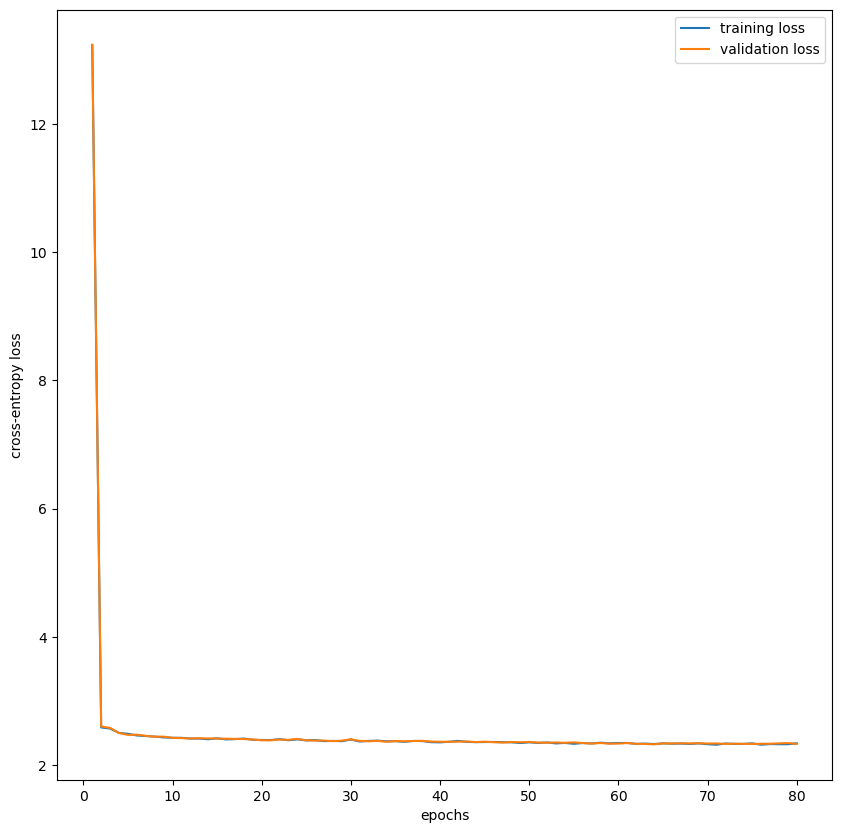

In [12]:
emb_dim = 2
out_dim = 100

# Set MLP parameters

# look-up table
C = torch.randn((num_chars, emb_dim), requires_grad=True)
# Internal layer
W = torch.randn((emb_dim*block_size, out_dim), requires_grad=True)
b = torch.randn(out_dim, requires_grad=True)
# Logits
W_log = torch.randn((out_dim, num_chars), requires_grad=True)
b_log = torch.randn(num_chars, requires_grad=True)

parameters = [C, W, b, W_log, b_log]

print(f"Number of trainable parameters: {sum(p.nelement() for p in parameters)}")

num_epochs = 4*int(1e4)
batch_size = 500
val_window = 100
lr = 0.1

train_losses, val_losses = train(num_epochs, batch_size, lr, val_window)

visualize(train_losses, val_losses)


## Visualize embeddings of characters

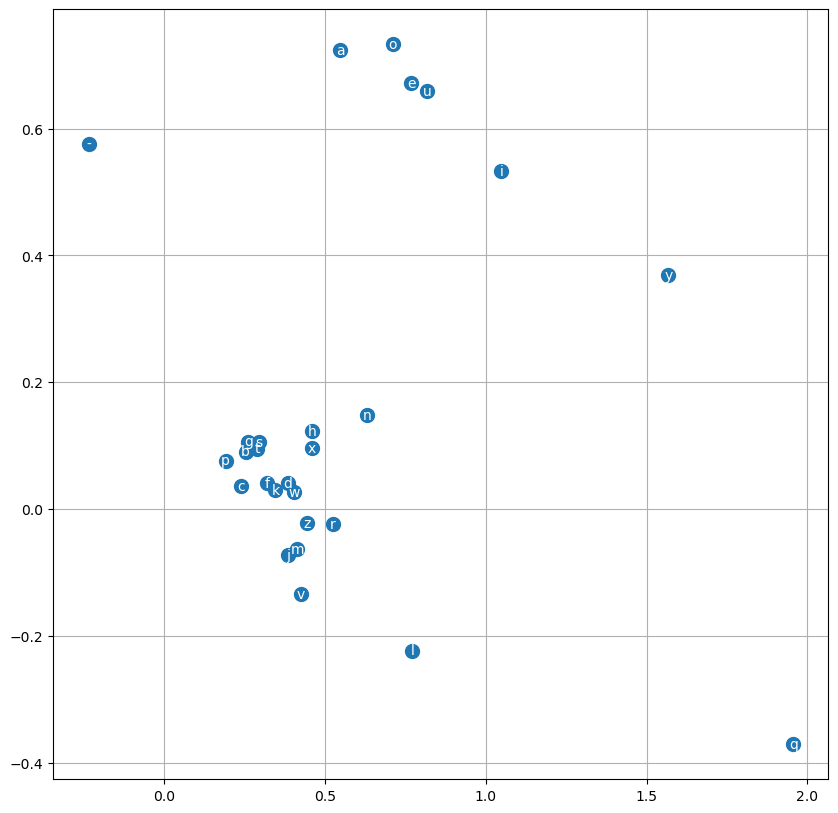

In [13]:
from sklearn.decomposition import PCA 

def visualize_embeddings():
    if C.shape[1] > 2:
        pca = PCA(n_components=2)
        X = pca.fit_transform(C.data) 
    else: 
        X = C.data        
    plt.figure(figsize=(10, 10))
    plt.scatter(X[:, 0].data, X[:, 1].data, s = 100)
    for i in range(C.shape[0]):
        plt.text(X[i, 0], X[i, 1], i_to_c[i], ha="center", va="center", color="white")
    plt.grid("minor")
    plt.show()

visualize_embeddings() 

# Generate name from trained model

In [14]:
@torch.no_grad()
def generate_from_model(starts_with=None):
    if starts_with is None:
        w = []
        x = torch.tensor([[0]*block_size], dtype=torch.long)
    else:
        w = [starts_with]
        x = torch.tensor([[0]*(block_size-1) + [c_to_i[starts_with]]], dtype=torch.long)
    while True:
        logits, _ = forward(x)
        P = F.softmax(logits, dim=1)
        next_idx = torch.multinomial(P, num_samples=1, replacement=True).item()
        if next_idx == 0:
            return "".join(w)
        w.append(i_to_c[next_idx])
        x = torch.cat([x[:, 1:], torch.tensor([[next_idx]], dtype=torch.long)], dim=1)
        

In [15]:
for _ in range(10):
    print(generate_from_model())

val
felahi
savarively
cai
ias
jael
cers
josyna
gadrila
ajy


---
# Fine-tune the MLP architecture  
---
In the following, we redefine the same model as above but wraping up the different parts into nice and tidy classes. We then apply optuna tuner to optimize for the model architecture: context size, embedding dimension and hidden-layer dimension.

    - After the optimization, the entropy loss is reduced substantially.
    - The model quality at generating name-like words also improves significantly

## MLP class

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, emb_dim, out_dim, block_size):
        super().__init__()
        self.block_size = block_size 
        self.emb_table = nn.Parameter(torch.randn(num_chars, emb_dim, dtype=torch.float), requires_grad=True)
        self.ln1 = nn.Linear(emb_dim*block_size, out_dim)
        self.ln2 = nn.Linear(out_dim, num_chars)

    def forward(self, x, y=None):
        """
        x has shape (batch_size, block_size). x[i, :] contains the integer tokens of the characters in the context for the i-th data point
        y has shape (batch_size, ). y[i] is the integer token of the character that follows the context for the i-th data point 
        """
        # embed tokenized-context data, concatenate along embedding dimension and apply first layer
        out = self.emb_table[x].view(x.shape[0], -1) # (batch_size, emb_dim*block_size)
        # first ffd
        out = self.ln1(out)
        # non-linear activation
        out = torch.tanh(out) 
        # get logits
        logits = self.ln2(out) # (batch_size, num_chars)
    
        if y is None:
            loss = None
        else:
            loss = F.cross_entropy(logits, y)
        return logits, loss 
        

## Process data

In [48]:
import os
import random

@torch.no_grad()
def generate_name_from_model(model: MLP, c_to_i: dict[str, int], i_to_c: dict[int, str], starts_with=None):
    block_size = model.block_size 
    if starts_with is None:
        w = []
        x = torch.tensor([[0]*block_size], dtype=torch.long)
    else:
        w = [starts_with]
        x = torch.tensor([[0]*(block_size-1) + [c_to_i[starts_with]]], dtype=torch.long)
    while True:
        logits, _ = model(x)
        P = F.softmax(logits, dim=1)
        next_idx = torch.multinomial(P, num_samples=1, replacement=True).item()
        if next_idx == 0:
            return "".join(w)
        w.append(i_to_c[next_idx])
        x = torch.cat([x[:, 1:], torch.tensor([[next_idx]], dtype=torch.long)], dim=1)

class DataProcessor:
    def __init__(self, split):
        self.load_data()
        self._get_mappings()
        self.split_data(split)

    def load_data(self):
        with open(os.getcwd() + "/../Data/names.txt", "r") as f:
            self.words = f.read().split("\n")

    def _get_mappings(self):
        chars = sorted(
            list(
                set("".join(self.words))
            ) + ['-']
        )
        self.num_chars = len(chars)
        self.i_to_c = {i: c for i, c in enumerate(chars)}
        self.c_to_i = {c: i for i, c in i_to_c.items()} 

    def split_data(self, split):
        random.shuffle(self.words)
        nt = int(split*len(self.words))
        self.train_words = self.words[:nt]
        self.test_words = self.words[nt:]
            

## Training class 

In [98]:
import torch.optim as optim
from sklearn.utils import gen_batches  

results_path = os.getcwd() + "/tuner_results"

def save_upload_model_state(model: MLP, trial: int, upload=True, path=None):
    file_path = results_path + (
        f"/model_state_dict_trial_{trial}.pt" if path is None
        else path
    )
    if not upload:
        torch.save(model.state_dict(), file_path)
    else:
        model.load_state_dict(torch.load(file_path, weights_only=True))
        return model         
        

class MLPTrainer:
    def __init__(self, emb_dim, out_dim, block_size, num_epochs, batch_size, data_processor: DataProcessor):
        self.emb_dim = emb_dim
        self.out_dim = out_dim
        self.data_processor = data_processor
        self.train_words = data_processor.train_words.copy() # to avoid modifying train_words attribute in DataProcessor class
        self.block_size = block_size
        self.lr=0.1
        self.num_epochs = num_epochs 
        self.batch_size = batch_size

    def _init_model(self):
        self.model = MLP(emb_dim=self.emb_dim, out_dim=self.out_dim, block_size=self.block_size)

    def _init_optimizer(self):
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def split_data(self, split):
        random.shuffle(self.train_words)
        nt = int(split*len(self.train_words))
        Xtr, Ytr = self.tokenize_data(self.train_words[:nt])
        Xval, Yval = self.tokenize_data(self.train_words[nt:])
        return (Xtr, Ytr), (Xval, Yval)
        
    def tokenize_data(self, words):
        X, Y = [], []
        for w in words:
            context = [0]*self.block_size
            for c in w+'-':
                X.append(context)
                Y.append(self.data_processor.c_to_i[c])
                # update context
                context = context[1:] + [self.data_processor.c_to_i[c]]
        return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long) 
    
    
    def generate_batches(self, data):
        X, Y = data
        train_batches = []
        for s in gen_batches(len(Y), batch_size=self.batch_size):
            train_batches.append((X[s], Y[s]))
        return train_batches 

    def gradient_step(self, x, y):
        self.optimizer.zero_grad()
        _, loss = self.model(x, y=y)
        loss.backward()
        self.optimizer.step()
        return loss.item()  
    
    def run_single_epoch(self, train_batches):
        loss = 0.0
        for x, y in train_batches:
            loss += self.gradient_step(x, y)
        return loss / len(train_batches)

    def run_epochs(self, trial: int):
        losses = []
        self._init_model()
        self._init_optimizer()
        train_data, val_data = self.split_data(split=0.9) 
        train_batches = self.generate_batches(train_data)
        for ep in tqdm(range(self.num_epochs), desc=f"Running epochs for trial {trial}"):
            if ep == int(0.8*self.num_epochs):
                # reduce learning rate for the last 20% of the epochs
                self.optimizer.param_groups[0]["lr"] /= 10   
            losses.append(self.run_single_epoch(train_batches))
        val_loss = self.validate(val_data)
        return val_loss, losses  

    @torch.no_grad()
    def validate(self, val_data):
        x, y = val_data
        _, loss = self.model(x, y=y)
        return loss.item()

    @staticmethod
    def visualize(losses):
        plt.plot(range(1, len(losses)+1), losses)
        plt.xlabel("epochs")
        plt.ylabel("entropy loss")
        plt.show() 

## Optuna tuner

In [77]:
import optuna
from dataclasses import dataclass, asdict
import json

@dataclass 
class TunerSettings:
    emb_dim_bounds: tuple[int]
    out_dim_bounds: tuple[int]
    num_epochs: int
    batch_size: int
    num_trials: int

    def dict(self):
        return asdict(self) 


class Tuner:
    def __init__(self, settings: TunerSettings, data_processor: DataProcessor):
        self.settings = settings
        self.data_processor = data_processor
        self.create_study() 

    def create_study(self):
        self.study = optuna.create_study(pruner=optuna.pruners.MedianPruner, direction="minimize")

    def suggest_train_params(self, trial: optuna.trial):
        _ = trial.suggest_int(name="block_size", low=1, high=5)
        _ = trial.suggest_int(name="emb_dim", low=self.settings.emb_dim_bounds[0], high=self.settings.emb_dim_bounds[1])
        _ = trial.suggest_int(name="out_dim", low=self.settings.out_dim_bounds[0], high=self.settings.out_dim_bounds[1])
        return trial.params 
    
    def objective(self, trial: optuna.trial):
        params = self.suggest_train_params(trial)
        params.update(
            {
                "data_processor": self.data_processor,
                "num_epochs": self.settings.num_epochs,
                "batch_size": self.settings.batch_size
            }
        )
        trainer = MLPTrainer(**params)
        try:
            loss, losses = trainer.run_epochs(trial.number)

            with open(results_path + f"/val_train_losses_trial_{trial.number}.json", "w") as f:
                json.dump({"val_loss": loss, "train_loss": losses[-1]}, f)
                
            save_upload_model_state(model=trainer.model, trial=trial.number, upload=False)
        except Exception as exc:
            loss = 1e6
            print(f"\nException {exc} occured during trial {trial.number}")
        return loss
    
    def optimize(self):
        self.study.optimize(self.objective, n_trials=self.settings.num_trials)
        
        print("Best architectural params:\n")
        for name, val in self.study.best_params.items():
            print('#'*4+f" {name} = {val}")
        print(f"\nwith validation loss: {self.study.best_value:.4f}")
        with open(results_path + f"/val_train_losses_trial_{self.study.best_trial.number}.json", "r") as f:
            d = json.load(f)
        print(f"with training loss: {d["train_loss"]:.4f}")
        tuner_results = self.settings.dict()
        tuner_results["best_trial"] = self.study.best_trial.number
        tuner_results.update(self.study.best_params)
        
        with open(results_path + "/tuner_settings_results.json", "w") as f:
            json.dump(tuner_results, f)
        

### Run tuner

In [78]:
settings = TunerSettings(
    emb_dim_bounds = (2, 10),
    out_dim_bounds = (30, 200),
    num_epochs = 80,
    batch_size = 500,
    num_trials = 20,
)

tuner = Tuner(
    settings=settings,
    data_processor=DataProcessor(split=0.9)  
)

tuner.optimize() 

[I 2026-04-29 17:43:00,456] A new study created in memory with name: no-name-a8f9c403-b936-4f84-8347-883d982a46fa
Running epochs for trial 0: 100%|███████████████| 80/80 [00:26<00:00,  3.05it/s]
[I 2026-04-29 17:43:26,927] Trial 0 finished with value: 2.541942834854126 and parameters: {'block_size': 1, 'emb_dim': 8, 'out_dim': 181}. Best is trial 0 with value: 2.541942834854126.
Running epochs for trial 1: 100%|███████████████| 80/80 [00:26<00:00,  3.04it/s]
[I 2026-04-29 17:43:53,495] Trial 1 finished with value: 2.246652126312256 and parameters: {'block_size': 5, 'emb_dim': 10, 'out_dim': 139}. Best is trial 1 with value: 2.246652126312256.
Running epochs for trial 2: 100%|███████████████| 80/80 [00:22<00:00,  3.63it/s]
[I 2026-04-29 17:44:15,615] Trial 2 finished with value: 2.305610179901123 and parameters: {'block_size': 2, 'emb_dim': 9, 'out_dim': 109}. Best is trial 1 with value: 2.246652126312256.
Running epochs for trial 3: 100%|███████████████| 80/80 [00:25<00:00,  3.19it/s]


Best architectural params:

block_size = 5
emb_dim = 5
out_dim = 102
with validation loss: 2.1927
with training loss: 2.1820


## Generate names from best model

In [87]:
def dummy_model_init(params):
    # instantiate model with appropriate architecture
    return MLP(
        emb_dim=params["emb_dim"],
        out_dim=params["out_dim"],
        block_size=params["block_size"]
    )

model = dummy_model_init(tuner.study.best_params)

# upload best model state dictionaty 
model = save_upload_model_state(
    model=model, 
    trial=tuner.study.best_trial.number, 
    upload=True
)

for _ in range(15):
    print(
        generate_name_from_model(
            model=model, 
            c_to_i=tuner.data_processor.c_to_i, 
            i_to_c=tuner.data_processor.i_to_c, 
        )
    )

omsae
miley
roser
jahry
caval
deylen
lure
kavi
elara
maxay


## Save best model

In [86]:
model = dummy_model_init(tuner.study.best_params)
model = save_upload_model_state(
    model=model, 
    trial=tuner.study.best_trial.number, 
    upload=True
)

save_upload_model_state(
    model=model, 
    trial=None, 
    upload=False,
    path="/best_models/model_state_one_time_lr_reduction.pt"
)

with open(results_path + "/best_models/architecture_one_time_lr_reduction.json", "w") as f:
    json.dump(tuner.study.best_params, f)


## Assess entropy loss of model on test data

In [94]:
def tokenize_data(words, block_size, c_to_i):
        X, Y = [], []
        for w in words:
            context = [0]*block_size
            for c in w+'-':
                X.append(context)
                Y.append(c_to_i[c])
                # update context
                context = context[1:] + [c_to_i[c]]
        return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

Xtest, Ytest = tokenize_data(
    words=tuner.data_processor.test_words,
    block_size=tuner.study.best_params["block_size"],
    c_to_i=tuner.data_processor.c_to_i,
)

def compute_minimum_entropy_loss(X, Y):
    Z = torch.cat([X, Y.view(-1, 1)], dim=-1)
    _, Nxy = torch.unique(Z, return_counts=True, dim=0)
    _, Nx = torch.unique(Z[:,:-1], return_counts=True, dim=0)
    Hxy = (Nxy * torch.log(Nxy)).sum()
    Hx = (Nx * torch.log(Nx)).sum()
    return -(Hxy - Hx) / Nxy.sum()

_, loss = model(Xtest, y=Ytest)

print(f"\nCross-entropy-loss of model over test data: {loss.item():.4f}")

min_loss = compute_minimum_entropy_loss(Xtest, Ytest)

print(f"\nMinimum possible value of cross-entropy loss given test data: {min_loss:.4f}")


Cross-entropy-loss of model over test data: 2.2043

Minimum possible value of cross-entropy loss given test data: 1.1527


---
---


# Appendix


---
---

# A1.- On cross-entropy loss and its minimum value (given the data)

---
## Log-likelihood for softmax probability generation and relation to cross-entropy loss
---

Let $y$ denote a target (label/token) we wish to predict and let $x$ denote the context that precedes the label $y$. The general setting for softmax prob. dist. generation is 
$$
P_\theta(y \mid x) := \frac{e^{x_\theta[y]}}{\sum\limits_{z} e^{x_\theta[z]}} 
$$

where $\theta$ denotes the (learnable) parameters of the model and $x_\theta$ denotes the (deterministically) generated logits, given $\theta$.

---
## Standard version of cross-entropy loss: negative log-likelihood of the data
---

Let $\mathcal D := \left\{ (x_m, y_m)\right\}_{m=1}^M$ denote the data where $x_m, y_m$ denote the context and label of the m-th input data, respectively. The mean negative log-likelihood of the data is:

$$
l(\mathcal D; \theta) := -\frac{1}{M} \sum\limits_{m=1}^M \log P_\theta(y_m \mid x_m) 
$$

This can be equivalently written as:

$$
l(\mathcal D;\theta) := -\sum\limits_{x}\sum\limits_{y} \frac{N(x, y)}{M} \log P_\theta(y \mid x) 
$$

where we sum over all possible target outcomes $y$ and all possible contexts $x$, in addition

$$
N(x,y) := \left|\left\{ (x_m, y_m)\in\mathcal D\mid x_m=x, y_m=y\right\}\right|
$$

---
## Relation to relative entropy
---

The data distribution is given by:

$$
\begin{align}
 &P(x, y) \equiv \frac{N(x, y)}{M}
\end{align}
$$


Thus, the negative log-likelihood of the data is the (conditional) relative entropy (cross-entropy) between the data distribution $P$ and the model-generated distribution $P_\theta$, that is: 

$$
l(\mathcal D; \theta) = -\sum\limits_{x, y} P(x, y) \log P_\theta(y \mid x)
$$

---
## Minimization of $l(\mathcal D;\theta)$
---

The above expression can be equivalently written as:

$$
\begin{align}
l(\mathcal D;\theta) &= -\sum\limits_{x, y} P(x, y) \log P_\theta(y \mid x)\\
& = -\sum\limits_{x, y} P(x, y) \left[\log \frac{P_\theta(y \mid x)}{P(y\mid x)} + \log P(y\mid x)\right]\\
& = \sum\limits_{x,y} P(x, y) \log\frac{P(y\mid x)}{P_\theta(y\mid x)} - \sum\limits_{x, y} P(x, y) \log P(y\mid x)\\
&=: \mathrm{KL}(P\parallel P_\theta) + H(P)
\end{align}
$$

where $\mathrm{KL}(P\parallel P_\theta)$ denotes the average Kullback-Leibler distance between the data distribution and the model distribution and $H(P)$ denotes the average Shannon entropy of the data distribution. Notice that $H(P)$ is independent of the model parameters (although it depends on the context choice, of course). 
In addition, it is a well-known property that $\mathrm{KL}(P\parallel P_\theta) \geq 0$ for arbitrary distributions $P, P_\theta$ and that the equality holds if and only if $P=P_\theta$. 

From this, we can already see that minimzing $l(\mathcal D;\theta)$ is equivalent to minimizing the Kullback-Leibler distance between model and data distributions. 

---
## Minimum value for cross-entropy loss
---

Since $\mathrm{KL}(P\parallel P_\theta) \geq 0$, we have the estimate

$$
\begin{align}
 l(\mathcal D;\theta) &\geq H(P) = - \frac{1}{M}\sum\limits_{x, y} N(x,y)\log \left(\frac{N(x,y)}{\sum\limits_{z} N(x, z)}\right)\\
 & = - \frac{1}{M}\left[\sum\limits_{x, y} N(x,y)\log N(x,y) - \sum\limits_{x} N(x)\log N(x)\right]
\end{align} 
$$

with $N(x):= \sum\limits_{y} N(x, y)$. Hence the quantity

$$
 l_0(\mathcal D) := - \frac{1}{M}\left[\sum\limits_{x, y} N(x,y)\log N(x,y) - \sum\limits_{x} N(x)\log N(x)\right]
$$

is the minimum possible value for the cross-entopy loss that we can achieve, given the data. 

# A2.- Modify the learning rate

## Direct method
Accessing the parameter via param_groups attribute:

In [68]:
trainer = MLPTrainer(emb_dim=2, out_dim=100, block_size=5, num_epochs=20, batch_size=500, data_processor=DataProcessor(split=0.9))
trainer._init_model()
trainer._init_optimizer()
print(f"Learning rate: {trainer.optimizer.param_groups[0]["lr"]}")
trainer.optimizer.param_groups[0]["lr"] /= 10
print(f"Learning rate after the modification: {trainer.optimizer.param_groups[0]["lr"]}")

Learning rate: 0.1
Learning rate after the modification: 0.01


## Via LambdaLR method in lr_scheduler

LambdaLR
class torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch=-1)[source]
Sets the initial learning rate.

The learning rate of each parameter group is set to the initial lr times a given function. When last_epoch=-1, sets initial lr as lr.

Parameters
:
optimizer (Optimizer) – Wrapped optimizer.

lr_lambda (function or list) – A function which computes a multiplicative factor given an integer parameter epoch, or a list of such functions, one for each group in optimizer.param_groups.

last_epoch (int) – The index of last epoch. Default: -1.

100%|██████████████████████████████████████████| 50/50 [00:00<00:00, 991.73it/s]


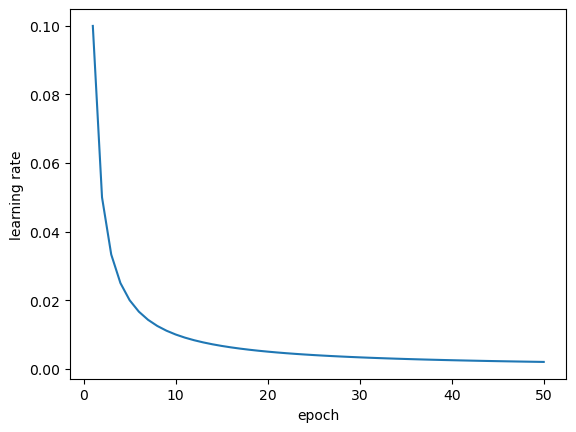

In [97]:
from torch.optim.lr_scheduler import LambdaLR

# define the epoch-dependece of the learning rate
lambda_lr = lambda epoch: 1/(epoch+1) # linear decay of lr along training epochs 

model = MLP(emb_dim=2, out_dim=10, block_size=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
x, y = get_batch(batch_size=1000, split="train")

scheduler = LambdaLR(optimizer, lr_lambda = lambda_lr)
lrs = []
num_epochs = 50
for _ in tqdm(range(num_epochs)):
    optimizer.zero_grad()
    _, loss = model(x, y=y)
    loss.backward()
    optimizer.step()
    lrs.append(optimizer.param_groups[0]["lr"])
    scheduler.step() 

plt.plot(range(1, num_epochs+1), lrs)
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.show() 




# A3.- Choose learning rate

We will trplicate the training loop bu with a learning rate that increases with the epoch. We will then print the loss as a function
of the learning rate. We choose the learning rate producing the lowest loss

## Dummy training loop

In [10]:
def dummy_train(num_epochs, batch_size, lr):
    # Set MLP parameters
    
    # look-up table
    C = torch.randn((num_chars, emb_dim), requires_grad=True)
    # Internal layer
    W = torch.randn((emb_dim*block_size, out_dim), requires_grad=True)
    b = torch.randn(out_dim, requires_grad=True)
    # Logits
    W_log = torch.randn((out_dim, num_chars), requires_grad=True)
    b_log = torch.randn(num_chars, requires_grad=True)

    parameters = [C, W, b, W_log, b_log]

    losses = []
    for ep in tqdm(range(num_epochs)):
        x, y = get_batch(batch_size=500, split="train")
        out = C[x].view(x.shape[0], -1) @ W + b # (batch_size, out_dim)
        # non-linear activation
        out = torch.tanh(out) 
        # get logits
        logits = out @ W_log + b_log # (batch_size, num_chars)
        loss = F.cross_entropy(logits, y)
        for p in parameters:
            p.grad = None
        loss.backward()
        for p in parameters:
            p.data += - lr * p.grad
        losses.append(loss.item())
    plt.plot(range(1, num_epochs+1), losses)
    plt.show()

## Choose an upper bound for lr

$l_r = 10$ seems to be already too big

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 1036.74it/s]


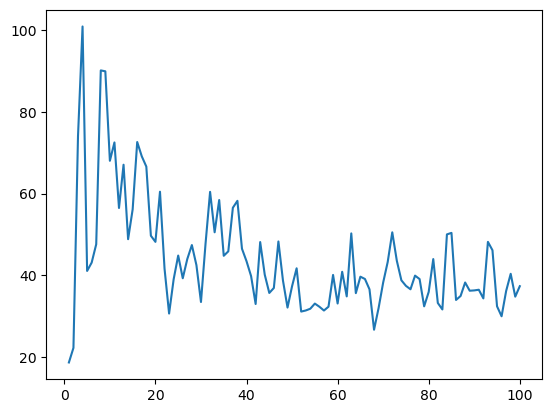

In [11]:
dummy_train(num_epochs=100, batch_size=500, lr=10)

$l_r = 1$ seems a reasonable upper bound

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 1103.04it/s]


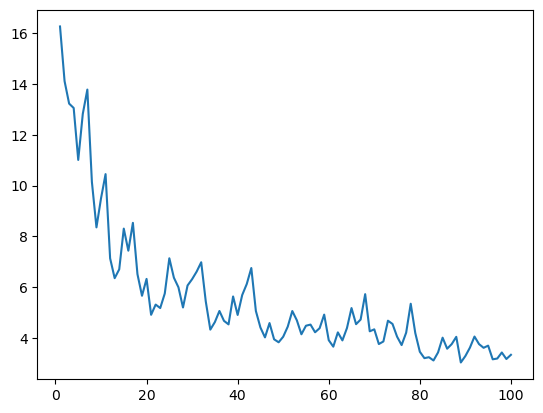

In [12]:
dummy_train(num_epochs=100, batch_size=500, lr=1)

## Choose a lower bound for lr

$l_r = 10^{-3}$ seems to be already too small

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 1057.70it/s]


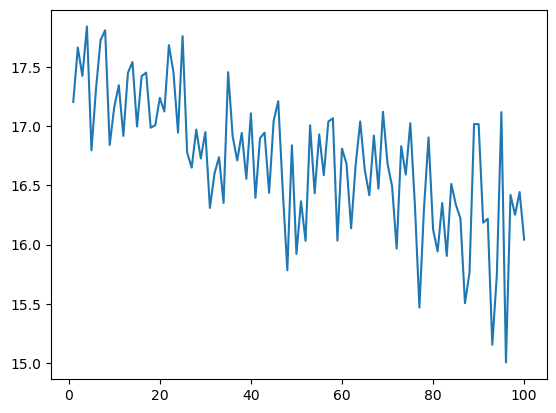

In [13]:
dummy_train(num_epochs=100, batch_size=500, lr=1e-3)

## Select a reasonable starting learning rate

In [14]:
def loss_vs_lr(lr_lower, lr_upper):
    # Set MLP parameters
    # look-up table
    C = torch.randn((num_chars, emb_dim), requires_grad=True)
    # Internal layer
    W = torch.randn((emb_dim*block_size, out_dim), requires_grad=True)
    b = torch.randn(out_dim, requires_grad=True)
    # Logits
    W_log = torch.randn((out_dim, num_chars), requires_grad=True)
    b_log = torch.randn(num_chars, requires_grad=True)

    parameters = [C, W, b, W_log, b_log]

    losses = []
    lr_exp = []

    # set learnin rates
    lrs = 10**torch.linspace(torch.log10(torch.tensor(lr_lower)), torch.log10(torch.tensor(lr_upper)), 1000)
    for lr in lrs:
        x, y = get_batch(batch_size=500, split="train")
        out = C[x].view(x.shape[0], -1) @ W + b # (batch_size, out_dim)
        # non-linear activation
        out = torch.tanh(out) 
        # get logits
        logits = out @ W_log + b_log # (batch_size, num_chars)
        loss = F.cross_entropy(logits, y)
        for p in parameters:
            p.grad = None
        loss.backward()
        for p in parameters:
            p.data += - lr * p.grad
        lr_exp.append(torch.log10(lr))
        losses.append(loss.item())
    plt.plot(lr_exp, losses)
    plt.xlabel("learning rate exponent")
    plt.ylabel("entropy loss")
    plt.show()    

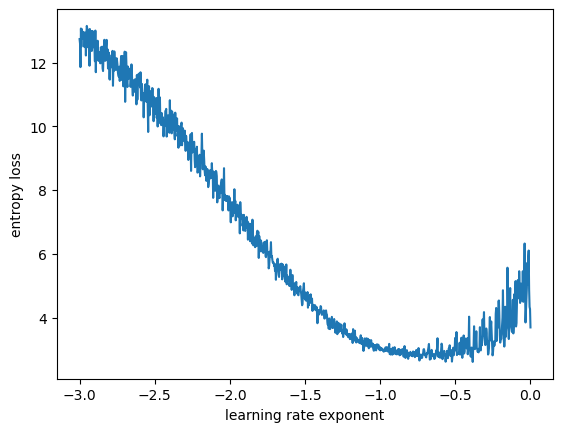

In [15]:
loss_vs_lr(1e-3, 1)

$lr = 0.1$ seems a reasonable starting learning rate